TAREA: Los ejemplos ilustrativos anteriores permiten saber el número de monedas presentes en la imagen ideal proporcionada. ¿Cómo determinar la cantidad de dinero presente en ella? A partir únicamente de las dimensiones, una sugerencia impicaríaj en primer término identificar de forma interactiva (por ejemplo haciendo clic en la imagen) una moneda de un valor fijo en la imagen (por ejemplo de 1€) para permitir establecer una relación entre píxeles y mo¡ilímetros. Tras obtener esa información y las dimensiones en milímetros de las distintas monedas, es factible calcular la cantidad de dinero en la imagen ideal.

Una vez resuelto el reto con la imagen ideal proporcionada, diseña un demostrador en vivo que a partir de la entrada de vídeo de la cámara, determine el dinero presente en la escena. Si bien 
no hay restricciones sobre utilizar medidas geométricas o de color, o cualquier clasificador, no deben hacer uso de modelos de aprendizaje profundo. ¿Funciona correctamente? ¿Se observan problemas?
Posibles extras serían la presencia de objetos que no son monedas y/o haya solape entre las monedas.

IMPORTANTE: No se admite el uso de modelos de aprendizaje profundo

Nota: Para establecer la correspondencia entre píxeles y milímetros, comentar que la moneda de un euro tiene un diámetro de 23.25 mm. la de 50 céntimos de 24.35, la de 20 céntimos de 22.25, etc. 

In [2]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
import math

0.5
0.1
0.2
1
2
0.01
0.02
0.05


Text(0.5, 1.0, 'Externos')

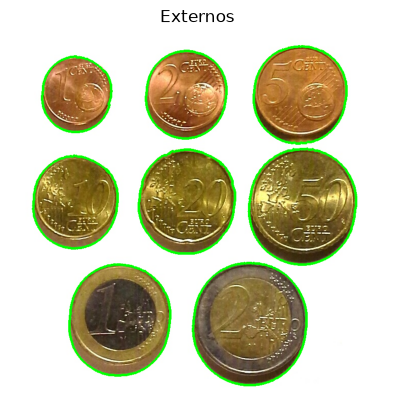

In [12]:
img = cv2.imread('Monedas2.jpg') 
img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


monedas_euro = {
    0.01: 207.39,
    0.02: 276.12,
    0.1: 306.35,
    0.05: 354.66,
    0.2: 388.82,
    1: 424.56,
    0.5: 461.86,
    2: 520.77
}


#umbral = 200 # Prueba varios comenzando en 130
# Umbralizado binario invertido, dado que por defecto se asume objetos en blanco
th1,img_th1 = cv2.threshold(img_gris,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
#img_th1 = cv2.adaptiveThreshold(img_gris, 255,
#    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
#    cv2.THRESH_BINARY_INV, 11, 2)

#Obtiene únicamente los contornos externos
contornos2, hierarchy2 = cv2.findContours(img_th1, 
    cv2.RETR_EXTERNAL , 
    cv2.CHAIN_APPROX_SIMPLE)

#Dibuja sobre la imagen de entrada sólo contornos externos
contornos =  []
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
for c in contornos2:
    area = cv2.contourArea(c)
    if area > 5:
        contornos.append(area)

escala = monedas_euro[0.01] / min(contornos)

for c in contornos:
    for m in monedas_euro.keys():
        if monedas_euro.get(m)* 0.945 <= c*escala <= monedas_euro.get(m) * 1.055:
            print(m)

cv2.drawContours(img_rgb, contornos2, -1, (0,255,0), 3)

plt.axis("off")
plt.imshow(img_rgb) 
plt.title('Externos')


In [ ]:
monedas_euro = {
    0.01: 207.39,
    0.02: 276.12,
    0.1: 306.35,
    0.05: 354.66,
    0.2: 388.82,
    1: 424.56,
    0.5: 461.86,
    2: 520.77
}

video = cv2.VideoCapture(0)

if video.isOpened():
    while True:
        ret, frame = video.read()

        img_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        th1,img_th1 = cv2.threshold(img_gris,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

        contornos2, hierarchy2 = cv2.findContours(img_th1, 
            cv2.RETR_EXTERNAL , 
            cv2.CHAIN_APPROX_SIMPLE)

        #Dibuja sobre la imagen de entrada sólo contornos externos
        contornos =  []
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        for c in contornos2:
            area = cv2.contourArea(c)
            if area > 5:
                contornos.append(area)

        escala = monedas_euro[0.01] / min(contornos)

        for c in contornos:
            for m in monedas_euro.keys():
                if monedas_euro.get(m)* 0.945 <= c*escala <= monedas_euro.get(m) * 1.055:
                    print(m)

        cv2.drawContours(frame, contornos2, -1, (0,255,0), 3)


        if ret:
            cv2.imshow('Video', frame)

        if cv2.waitKey(20) == 27:
            break

    video.release()
    cv2.destroyAllWindows()

In [17]:
import math

video = cv2.VideoCapture(0)

if video.isOpened():
    while True:
        ret, frame = video.read()
        if not ret:
            break

        img_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        th1, img_th1 = cv2.threshold(img_gris, 0, 255,
                                     cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        # Limpia ruido pequeño antes de buscar contornos
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        img_th1 = cv2.morphologyEx(img_th1, cv2.MORPH_OPEN, kernel)

        contornos2, _ = cv2.findContours(img_th1,
                                         cv2.RETR_EXTERNAL,
                                         cv2.CHAIN_APPROX_SIMPLE)

        contornos_validos = []
        areas = []
        for c in contornos2:
            area = cv2.contourArea(c)
            if area < 100:          # sube/baja según el tamaño de tus monedas
                continue

            (x, y), r = cv2.minEnclosingCircle(c)
            ratio = area / (math.pi * r * r)

            perimetro = cv2.arcLength(c, True)
            circ = 4 * math.pi * area / (perimetro ** 2) if perimetro > 0 else 0

            if ratio > 0.85:
                contornos_validos.append(c)
                areas.append(area)

        if areas:
            escala = monedas_euro[0.01] / min(areas)
            for a in areas:
                for m, ref in monedas_euro.items():
                    if ref * 0.945 <= a * escala <= ref * 1.055:
                        print(m)

        cv2.drawContours(frame, contornos_validos, -1, (0, 255, 0), 3)
        cv2.imshow('Video', frame)

        if cv2.waitKey(20) == 27:
            break

    video.release()
    cv2.destroyAllWindows()